## Libs

In [1]:

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.datasets import make_moons


from tqdm import tqdm

import optuna
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")



Usando dispositivo: cuda


d:\programming\26.1\IAP\MLP_implementation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Classe do MLP

In [2]:
class MLP(nn.Module):
    def __init__(
        self,
        input_size,
        num_classes,
        hidden_sizes,
        dropout_rate,
        learning_rate,
        momentum,
        activation_func,
        optimizer_class,
    ):
        super(MLP, self).__init__()
        layers = []
        in_layer = input_size
        self.learning_rate = learning_rate
        self.momentum = momentum
        
        # Construir camadas da rede
        for h_size in hidden_sizes:
            layers.append(nn.Linear(in_layer, h_size))
            layers.append(activation_func)
            layers.append(nn.Dropout(dropout_rate))
            in_layer = h_size

        # Camada de saída
        layers.append(nn.Linear(in_layer, num_classes))
        self.model = nn.Sequential(*layers)

        if optimizer_class == torch.optim.SGD:
            self.optimizer = optimizer_class(
                self.parameters(), lr=learning_rate, momentum=momentum
            )
        else:
            self.optimizer = optimizer_class(self.parameters(), lr=learning_rate)

    def forward(self, x):
        return self.model(x)


## Funções para Treinamento e Tunning

### Preparar Dados como Dataloaders

In [41]:
# format data to dataloaders 
def format_data(X, y, batch_size=32, shuffle=True):
    dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long))
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return dataloader

### Treino por época

In [3]:
def train_epoch(model, dataloader, loss_func, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        model.optimizer.zero_grad()
        outputs = model(X_batch)
        loss = loss_func(outputs, y_batch)
        loss.backward()
        model.optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(dataloader.dataset)


### Validação

In [4]:
def validate(model, dataloader, loss_func, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = loss_func(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            all_preds.append(outputs.cpu())
            all_labels.append(y_batch.cpu())
    avg_loss = total_loss / len(dataloader.dataset)
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    return avg_loss, all_preds, all_labels

### Tunning

In [29]:


def create_objective(X, y, num_epochs, device, batch_size=32):
    hyperparam_dict = {
        "hidden_sizes": [[64], [128], [64, 32], [128, 64]],
        "dropout_rate": (0.0, 0.5),
        "learning_rate": (1e-4, 1e-1),
        "momentum": (0.0, 0.9),
        "activation_func": [nn.ReLU(), nn.Tanh(), nn.Sigmoid()],
        "optimizer_class": [torch.optim.SGD, torch.optim.Adam],
    }
    input_size = X.shape[1]
    num_classes = len(np.unique(y))
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)

    def objective(trial):
        # Hiperparâmetros a serem otimizados
        hidden_sizes = trial.suggest_categorical("hidden_sizes", hyperparam_dict["hidden_sizes"])
        learning_rate = trial.suggest_float("learning_rate", *hyperparam_dict["learning_rate"], log=True)
        momentum = trial.suggest_float("momentum", *hyperparam_dict["momentum"])
        dropout_rate = trial.suggest_float("dropout_rate", *hyperparam_dict["dropout_rate"])
        activation_func = trial.suggest_categorical("activation_func", hyperparam_dict["activation_func"])
        optimizer_class = trial.suggest_categorical("optimizer_class", hyperparam_dict["optimizer_class"])

        # Validação cruzada
        k = 5
        folds = KFold(n_splits=k, shuffle=True, random_state=42)
        val_losses = []
        val_accuracies = []

        for fold, (train_idx, val_idx) in enumerate(folds.split(X)):
            
            # Modelo e função de custo
            model = MLP(
                input_size=input_size,
                num_classes=num_classes,
                hidden_sizes=hidden_sizes,
                dropout_rate=dropout_rate,
                learning_rate=learning_rate,
                momentum=momentum,
                activation_func=activation_func,
                optimizer_class=optimizer_class,
            ).to(device)

            loss_func = nn.CrossEntropyLoss()

            # Dados
            train_subset = Subset(TensorDataset(
                    X_tensor[train_idx], 
                    y_tensor[train_idx]), 
                    range(len(train_idx))
                    )
            val_subset = Subset(TensorDataset(
                X_tensor[val_idx], 
                y_tensor[val_idx]), 
                range(len(val_idx))
                )
            train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(val_subset, batch_size=batch_size)


            for epoch in range(num_epochs):
                train_epoch(model, train_loader, loss_func, device)

            # Validar no fold atual
            val_loss_fold, all_preds, all_labels = validate(model, val_loader, loss_func, device)
            accuracy = accuracy_score(all_labels.numpy(), all_preds.argmax(dim=1).numpy())

            print(f"Fold {fold+1}/{k} - Val Loss: {val_loss_fold:.4f} - Accuracy: {accuracy:.4f}")

            val_losses.append(val_loss_fold)
            val_accuracies.append(accuracy)

        # Retornar acuracia media
        return np.mean(val_accuracies)

    return objective

                

## Criacao de Dataset e Busca de Parametros

In [50]:


# test with make mooons first
feature_set_X, labels_y = make_moons(n_samples=2000, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(feature_set_X, labels_y, stratify=labels_y, test_size=0.1, random_state=42)


In [7]:
print("Shapes treino e teste:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

Shapes treino e teste: (1800, 2) (1800,) (200, 2) (200,)


In [8]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='optuna')

study = optuna.create_study(direction="maximize")
objective_fun = create_objective(X_train, y_train, num_epochs=50, device=device)
study.optimize(objective_fun, n_trials=10)

[I 2026-04-07 13:09:41,391] A new study created in memory with name: no-name-27d3f380-c14f-4dd2-891e-41b950e4cfbd


Fold 1/5 - Val Loss: 0.3087 - Accuracy: 0.8556
Fold 2/5 - Val Loss: 0.3196 - Accuracy: 0.8583
Fold 3/5 - Val Loss: 0.3256 - Accuracy: 0.8333
Fold 4/5 - Val Loss: 0.3494 - Accuracy: 0.8194


[I 2026-04-07 13:10:22,999] Trial 0 finished with value: 0.8377777777777776 and parameters: {'hidden_sizes': [64, 32], 'learning_rate': 0.005324202111906904, 'momentum': 0.8109677676508694, 'dropout_rate': 0.26098256310828655, 'activation_func': Sigmoid(), 'optimizer_class': <class 'torch.optim.sgd.SGD'>}. Best is trial 0 with value: 0.8377777777777776.


Fold 5/5 - Val Loss: 0.3509 - Accuracy: 0.8222
Fold 1/5 - Val Loss: 0.0044 - Accuracy: 1.0000
Fold 2/5 - Val Loss: 0.0022 - Accuracy: 1.0000
Fold 3/5 - Val Loss: 0.0086 - Accuracy: 0.9972
Fold 4/5 - Val Loss: 0.0037 - Accuracy: 1.0000


[I 2026-04-07 13:10:47,095] Trial 1 finished with value: 0.9988888888888889 and parameters: {'hidden_sizes': [64], 'learning_rate': 0.009689474171355161, 'momentum': 0.07091706432970463, 'dropout_rate': 0.3073248227733725, 'activation_func': ReLU(), 'optimizer_class': <class 'torch.optim.adam.Adam'>}. Best is trial 1 with value: 0.9988888888888889.


...

Fold 5/5 - Val Loss: 0.0084 - Accuracy: 0.9972
Fold 1/5 - Val Loss: 0.0004 - Accuracy: 1.0000
Fold 2/5 - Val Loss: 0.0005 - Accuracy: 1.0000
Fold 3/5 - Val Loss: 0.0076 - Accuracy: 0.9972
Fold 4/5 - Val Loss: 0.0001 - Accuracy: 1.0000


[I 2026-04-07 13:13:47,184] Trial 8 finished with value: 0.9983333333333334 and parameters: {'hidden_sizes': [128, 64], 'learning_rate': 0.005769768641171364, 'momentum': 0.1974836872800192, 'dropout_rate': 0.1958608172467206, 'activation_func': Tanh(), 'optimizer_class': <class 'torch.optim.adam.Adam'>}. Best is trial 1 with value: 0.9988888888888889.


Fold 5/5 - Val Loss: 0.0092 - Accuracy: 0.9944
Fold 1/5 - Val Loss: 0.5736 - Accuracy: 0.7944
Fold 2/5 - Val Loss: 0.5479 - Accuracy: 0.8083
Fold 3/5 - Val Loss: 0.5627 - Accuracy: 0.7889
Fold 4/5 - Val Loss: 0.5750 - Accuracy: 0.7417


[I 2026-04-07 13:14:07,685] Trial 9 finished with value: 0.7861111111111111 and parameters: {'hidden_sizes': [64], 'learning_rate': 0.0003225307820658576, 'momentum': 0.5485567033848545, 'dropout_rate': 0.4025560067804801, 'activation_func': Sigmoid(), 'optimizer_class': <class 'torch.optim.sgd.SGD'>}. Best is trial 1 with value: 0.9988888888888889.


Fold 5/5 - Val Loss: 0.5738 - Accuracy: 0.7972


### Melhores parâmetros encontrados

In [9]:
best_params = {
    'hidden_sizes': [64], 
    'learning_rate': 0.009689474171355161, 
    'momentum': 0.07091706432970463, # Não usado já que é Adam como otimizador
    'dropout_rate': 0.3073248227733725, 
    'activation_func': nn.ReLU(), 
    'optimizer_class': torch.optim.Adam
    }


## Avaliação Final

In [35]:
best_model = MLP(
    input_size=X_train.shape[1],
    num_classes=len(np.unique(y_train)),
    hidden_sizes=best_params["hidden_sizes"],
    dropout_rate=best_params["dropout_rate"],
    learning_rate=best_params["learning_rate"],
    momentum=best_params["momentum"],
    activation_func=best_params["activation_func"],
    optimizer_class=best_params["optimizer_class"],
).to(device)

print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'hidden_sizes': [64], 'learning_rate': 0.009689474171355161, 'momentum': 0.07091706432970463, 'dropout_rate': 0.3073248227733725, 'activation_func': ReLU(), 'optimizer_class': <class 'torch.optim.adam.Adam'>}


In [42]:
# preparar dataloader de treino e teste
train_loader = format_data(X_train, y_train, batch_size=32, shuffle=True)
test_loader = format_data(X_test, y_test, batch_size=32, shuffle=False)

In [36]:
# Treinar modelo final com os melhores hiperparâmetros
num_epochs = 50
for epoch in range(num_epochs):
    train_loss = train_epoch(best_model, train_loader, nn.CrossEntropyLoss(), device)
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}")

Epoch 1/50 - Train Loss: 0.2862
Epoch 2/50 - Train Loss: 0.1678
Epoch 3/50 - Train Loss: 0.1116
Epoch 4/50 - Train Loss: 0.0799
Epoch 5/50 - Train Loss: 0.0641
Epoch 6/50 - Train Loss: 0.0528
Epoch 7/50 - Train Loss: 0.0455
Epoch 8/50 - Train Loss: 0.0334
Epoch 9/50 - Train Loss: 0.0254
Epoch 10/50 - Train Loss: 0.0287
Epoch 11/50 - Train Loss: 0.0288
Epoch 12/50 - Train Loss: 0.0202
Epoch 13/50 - Train Loss: 0.0205
Epoch 14/50 - Train Loss: 0.0205
Epoch 15/50 - Train Loss: 0.0186
Epoch 16/50 - Train Loss: 0.0204
Epoch 17/50 - Train Loss: 0.0156
Epoch 18/50 - Train Loss: 0.0154
Epoch 19/50 - Train Loss: 0.0186
Epoch 20/50 - Train Loss: 0.0158
Epoch 21/50 - Train Loss: 0.0227
Epoch 22/50 - Train Loss: 0.0160
Epoch 23/50 - Train Loss: 0.0136
Epoch 24/50 - Train Loss: 0.0140
Epoch 25/50 - Train Loss: 0.0150
Epoch 26/50 - Train Loss: 0.0131
Epoch 27/50 - Train Loss: 0.0087
Epoch 28/50 - Train Loss: 0.0138
Epoch 29/50 - Train Loss: 0.0132
Epoch 30/50 - Train Loss: 0.0064
Epoch 31/50 - Train

In [49]:
# Previsão no dataset de treino
train_loss, all_preds_train, all_labels_train = validate(best_model, train_loader, nn.CrossEntropyLoss(), device)
train_accuracy = accuracy_score(all_labels_train.numpy(), all_preds_train.argmax(dim=1).numpy())
print(f"Train Loss: {train_loss:.4f} - Train Accuracy: {train_accuracy:.4f}")

Train Loss: 0.0029 - Train Accuracy: 0.9989


In [44]:
# Previsão no dataset de teste 
test_loss, all_preds, all_labels = validate(best_model, test_loader, nn.CrossEntropyLoss(), device)
all_preds_np = all_preds.argmax(dim=1).numpy()
all_labels_np = all_labels.numpy()

test_accuracy = accuracy_score(all_labels_np, all_preds_np)
print(f"Test Loss: {test_loss:.4f} - Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.0039 - Test Accuracy: 1.0000


In [45]:
# Calcular outras metricas além da acurácia
precision = precision_score(all_labels_np, all_preds_np, average='weighted')
recall = recall_score(all_labels_np, all_preds_np, average='weighted')
f1 = f1_score(all_labels_np, all_preds_np, average='weighted')
print(f"Precision: {precision:.4f} - Recall: {recall:.4f} - F1 Score: {f1:.4f}")

Precision: 1.0000 - Recall: 1.0000 - F1 Score: 1.0000


Text(0.5, 1.0, 'Acurácia de Treino vs Teste')

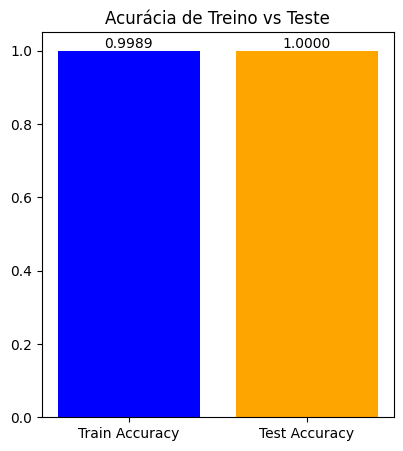

In [66]:
# Plotar graficos comparando metricas entre treino e teste
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
bars1 = plt.bar(['Train Accuracy', 'Test Accuracy'], [train_accuracy, test_accuracy], color=['blue', 'orange'])
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}', ha='center', va='bottom')
plt.title('Acurácia de Treino vs Teste')

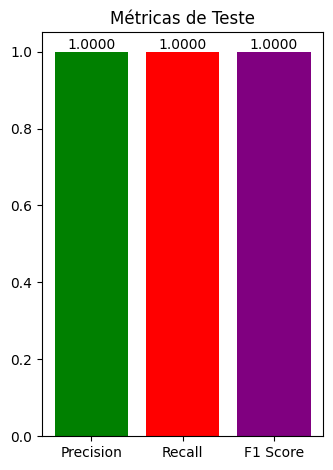

In [67]:
# Plotar demais metricas de teste
plt.subplot(1, 2, 2)
bars2 = plt.bar(['Precision', 'Recall', 'F1 Score'], [precision, recall, f1], color=['green', 'red', 'purple'])
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}', ha='center', va='bottom')
plt.title('Métricas de Teste')
plt.tight_layout()

## Fronteira de Decisão

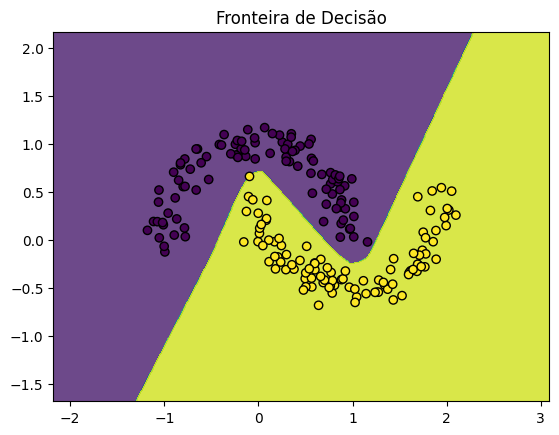

In [39]:
# Visualizar fronteira de decisão
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)
    with torch.no_grad():
        Z = model(grid).cpu().numpy()
    Z = Z.argmax(axis=1).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.title("Fronteira de Decisão")
    plt.show()
    
plot_decision_boundary(best_model, X_test, y_test)
